In [1]:
# Install sentence-transformers library
!pip install sentence-transformers

In [4]:
# Import all required libraries
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 10 sentences across 3 topics: Cricket, Cooking, Cybersecurity
sentences = [
    # Cricket (4 sentences) — index 0 to 3
    "The batsman hit a magnificent six over the boundary.",
    "India won the test match by an innings and 50 runs.",
    "The spinner bowled a googly that deceived the batsman completely.",
    "The fielder took a stunning catch near the boundary rope.",

    # Cooking (3 sentences) — index 4 to 6
    "Saute the onions in olive oil until they turn golden brown.",
    "Always preheat the oven to 180 degrees before baking a cake.",
    "Add a pinch of turmeric and cumin to enhance the flavour of the curry.",

    # Cybersecurity (3 sentences) — index 7 to 9
    "A phishing attack tricks users into revealing their passwords.",
    "Firewalls monitor incoming and outgoing network traffic to block threats.",
    "Two-factor authentication adds an extra layer of security to your account."
]

print(f"Total sentences: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"{i+1}. {s}")

Total sentences: 10
1. The batsman hit a magnificent six over the boundary.
2. India won the test match by an innings and 50 runs.
3. The spinner bowled a googly that deceived the batsman completely.
4. The fielder took a stunning catch near the boundary rope.
5. Saute the onions in olive oil until they turn golden brown.
6. Always preheat the oven to 180 degrees before baking a cake.
7. Add a pinch of turmeric and cumin to enhance the flavour of the curry.
8. A phishing attack tricks users into revealing their passwords.
9. Firewalls monitor incoming and outgoing network traffic to block threats.
10. Two-factor authentication adds an extra layer of security to your account.


In [5]:
# Load the model and generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print(f"Embedding shape: {embeddings.shape}")
print("Each sentence is now a vector of 384 numbers")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)
Each sentence is now a vector of 384 numbers


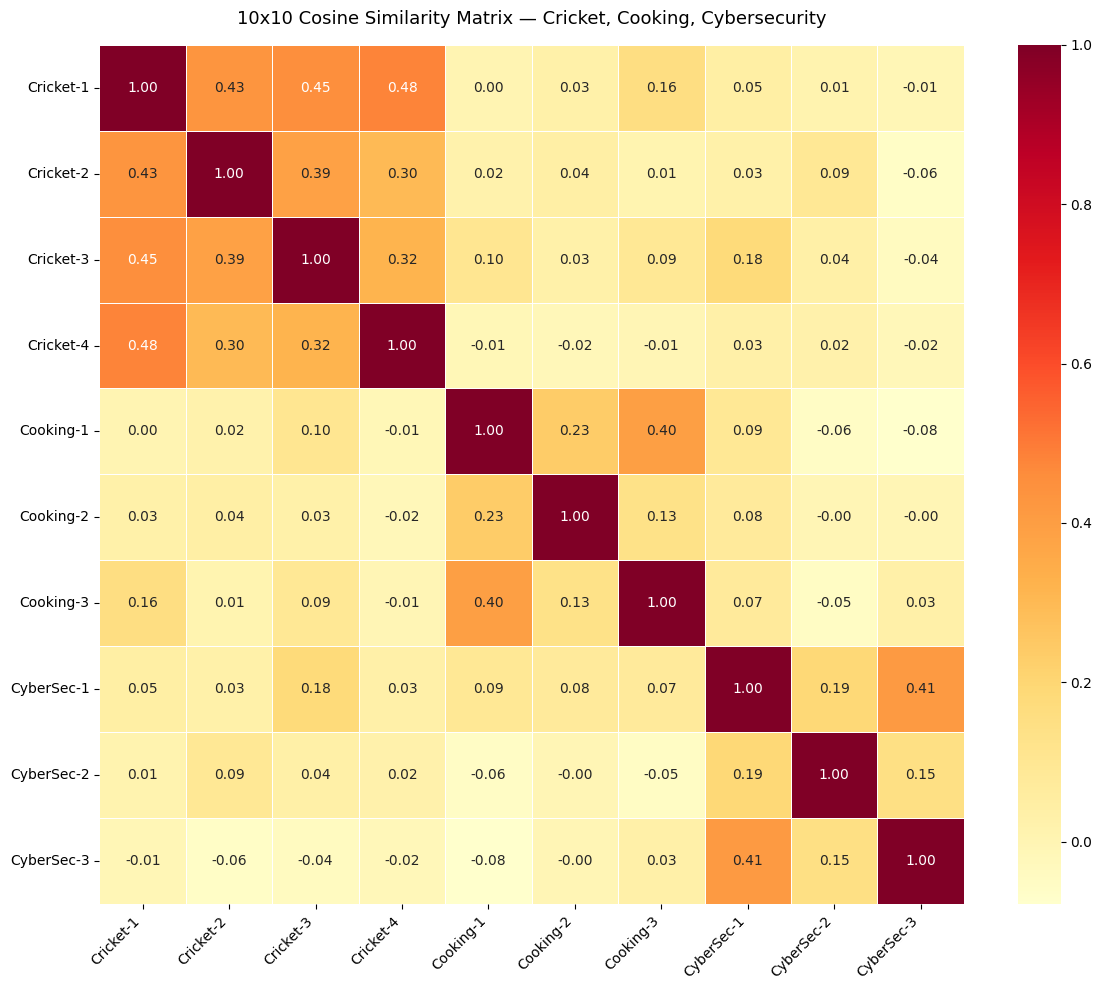

In [6]:
# Compute the 10x10 cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Labels for the heatmap
labels = [
    "Cricket-1", "Cricket-2", "Cricket-3", "Cricket-4",
    "Cooking-1", "Cooking-2", "Cooking-3",
    "CyberSec-1", "CyberSec-2", "CyberSec-3"
]

# Draw the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("10x10 Cosine Similarity Matrix — Cricket, Cooking, Cybersecurity",
          fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Query sentence given in the assignment
query = "The bowler took three wickets in one over"

# Generate embedding for the query
query_embedding = model.encode([query])

# Compute similarity between query and all 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar (sorted highest first)
top2_indices = np.argsort(query_similarities)[::-1][:2]

print(f"Query: '{query}'")
print()
print("Top 2 Most Similar Sentences:")
print("-" * 50)
for rank, idx in enumerate(top2_indices, 1):
    print(f"Rank {rank}: {sentences[idx]}")
    print(f"Similarity Score: {query_similarities[idx]:.4f}")
    print()

Query: 'The bowler took three wickets in one over'

Top 2 Most Similar Sentences:
--------------------------------------------------
Rank 1: The spinner bowled a googly that deceived the batsman completely.
Similarity Score: 0.5588

Rank 2: The batsman hit a magnificent six over the boundary.
Similarity Score: 0.5549

